In [37]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [38]:
crop = pd.read_csv(r"C:\Users\sruja\Downloads\soyabean_bidar_data.csv")
crop.head()

,Location,Area,Rainfall,Temperature,Soil_Type,Nitrogen,Phosphorus,Potassium,Humidity,Yield(kg/ha),Season
0,Humnabad,729,1333.06,29.41,Laterite Soil,77,20,45,60.38,4700,Kharif
1,Bhalki,971,1003.52,28.21,Red Soil,63,31,30,65.42,4240,Kharif
2,Bhalki,1299,916.91,30.35,Red Soil,78,33,39,94.50,4237,Kharif
3,Bhalki,1312,1144.97,25.83,Black Soil,47,37,36,71.19,4481,Kharif
4,Bhalki,1035,1249.63,21.58,Red Soil,72,40,44,63.81,4700,Kharif


In [39]:
crop.shape

(3500, 11)

In [40]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      3500 non-null   object 
 1   Area          3500 non-null   int64  
 2   Rainfall      3500 non-null   float64
 3   Temperature   3500 non-null   float64
 4   Soil_Type     3500 non-null   object 
 5   Nitrogen      3500 non-null   int64  
 6   Phosphorus    3500 non-null   int64  
 7   Potassium     3500 non-null   int64  
 8   Humidity      3500 non-null   float64
 9   Yield(kg/ha)  3500 non-null   int64  
 10  Season        3500 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 300.9+ KB


In [41]:
crop.isnull().sum()

Location        0
Area            0
Rainfall        0
Temperature     0
Soil_Type       0
Nitrogen        0
Phosphorus      0
Potassium       0
Humidity        0
Yield(kg/ha)    0
Season          0
dtype: int64

In [42]:
crop.duplicated().sum()

0

In [43]:
crop.describe()

,Area,Rainfall,Temperature,Nitrogen,Phosphorus,Potassium,Humidity,Yield(kg/ha)
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,825.738857,1206.566631,26.411237,62.056571,34.535714,44.537429,77.318543,4555.404286
std,388.326161,172.993715,3.723161,10.159162,8.619261,8.580971,10.078077,191.232483
min,150.000000,900.030000,20.000000,45.000000,20.000000,30.000000,60.000000,3924.000000
25%,492.000000,1056.402500,23.200000,53.000000,27.000000,37.000000,68.570000,4421.000000
50%,825.000000,1209.920000,26.460000,62.000000,35.000000,45.000000,77.270000,4697.000000
75%,1161.000000,1355.410000,29.540000,71.000000,42.000000,52.000000,86.112500,4700.000000
max,1499.000000,1499.790000,33.000000,79.000000,49.000000,59.000000,94.990000,4700.000000


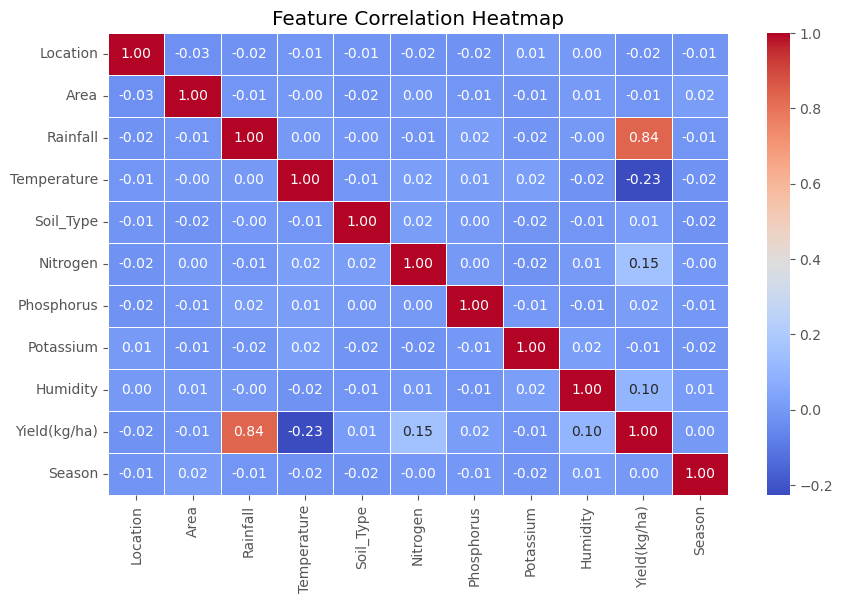

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Copy dataset to avoid modifying original
df_encoded = crop.copy()

# Convert categorical columns using Label Encoding
categorical_features = ["Location", "Soil_Type", "Season"]
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # Store encoders if needed later

# Compute correlation matrix on the numeric dataset
correlation_matrix = df_encoded.corr()

# Display correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [45]:
len(crop['Location'].unique())

5

In [46]:
len(crop['Soil_Type'].unique())

3

In [47]:
len(crop['Season'].unique())

2

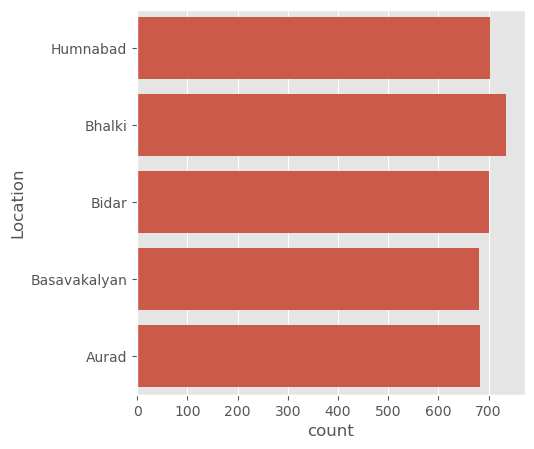

In [48]:
plt.figure(figsize=(5,5))
sns.countplot(y = crop['Location'])
plt.show()

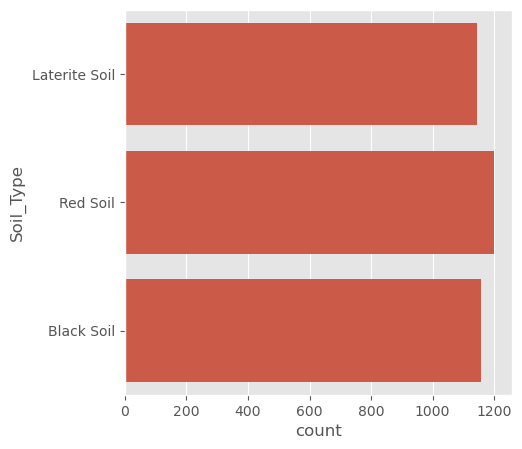

In [49]:
plt.figure(figsize=(5,5))
sns.countplot(y = crop['Soil_Type'])
plt.show()

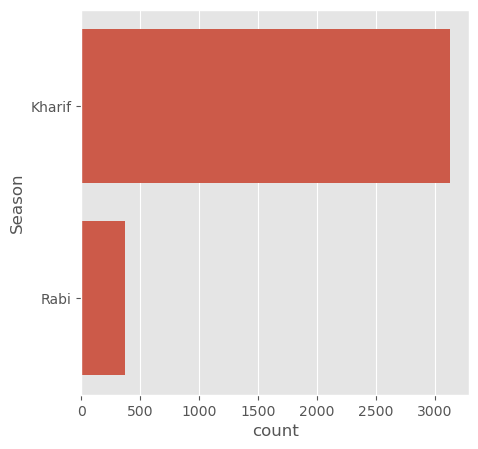

In [50]:
plt.figure(figsize=(5,5))
sns.countplot(y = crop['Season'])
plt.show()

In [51]:
crop.columns

Index(['Location', 'Area', 'Rainfall', 'Temperature', 'Soil_Type', 'Nitrogen',
       'Phosphorus', 'Potassium', 'Humidity', 'Yield(kg/ha)', 'Season'],
      dtype='object')

In [54]:
col=['Area','Rainfall','Temperature','Nitrogen','Phosphorus','Potassium','Humidity','Location','Soil_Type','Season','Yield(kg/ha)']

In [55]:
df=crop[col]

In [56]:
df.head()

,Area,Rainfall,Temperature,Nitrogen,Phosphorus,Potassium,Humidity,Location,Soil_Type,Season,Yield(kg/ha)
0,729,1333.06,29.41,77,20,45,60.38,Humnabad,Laterite Soil,Kharif,4700
1,971,1003.52,28.21,63,31,30,65.42,Bhalki,Red Soil,Kharif,4240
2,1299,916.91,30.35,78,33,39,94.50,Bhalki,Red Soil,Kharif,4237
3,1312,1144.97,25.83,47,37,36,71.19,Bhalki,Black Soil,Kharif,4481
4,1035,1249.63,21.58,72,40,44,63.81,Bhalki,Red Soil,Kharif,4700


In [57]:
X = df.drop('Yield(kg/ha)', axis = 1)
y = df['Yield(kg/ha)']

In [58]:
X.shape

(3500, 10)

In [59]:
y.shape

(3500,)

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.1, random_state = 0, shuffle=True)

In [61]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

ohe = OneHotEncoder(drop = 'first')
scale = StandardScaler()

preprocesser = ColumnTransformer(
    transformers = [
        ('StandardScale', scale, [0,1,2,3,4,5,6]),
        ('OneHotEncode', ohe, [7,8,9])
    ], 
    remainder = 'passthrough'
) 

In [62]:
X_train_dummy = preprocesser.fit_transform(X_train)
X_test_dummy  = preprocesser.fit_transform(X_test)

In [70]:
preprocesser.get_feature_names_out(col[:-1])

array(['StandardScale__Area', 'StandardScale__Rainfall',
       'StandardScale__Temperature', 'StandardScale__Nitrogen',
       'StandardScale__Phosphorus', 'StandardScale__Potassium',
       'StandardScale__Humidity', 'OneHotEncode__Location_Basavakalyan',
       'OneHotEncode__Location_Bhalki', 'OneHotEncode__Location_Bidar',
       'OneHotEncode__Location_Humnabad',
       'OneHotEncode__Soil_Type_Laterite Soil',
       'OneHotEncode__Soil_Type_Red Soil', 'OneHotEncode__Season_Rabi'],
      dtype=object)

In [71]:
file_path = r"C:\Users\sruja\Downloads\soyabean_bidar_data.csv"
df = pd.read_csv(file_path)
print(df.isnull().sum()) 

Location        0
Area            0
Rainfall        0
Temperature     0
Soil_Type       0
Nitrogen        0
Phosphorus      0
Potassium       0
Humidity        0
Yield(kg/ha)    0
Season          0
dtype: int64


In [72]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score

file_path = r"C:\Users\sruja\Downloads\soyabean_bidar_data.csv"
df = pd.read_csv(file_path)

categorical_features = ['Location', 'Soil_Type', 'Season']
numerical_features = ['Area', 'Rainfall', 'Temperature', 'Nitrogen', 'Phosphorus', 'Potassium', 'Humidity']
target_variable = "Yield(kg/ha)"

X = df[numerical_features + categorical_features]
y = df[target_variable]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_transformed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.3, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

best_rf_model = grid_search.best_estimator_

y_pred = best_rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = max(0, r2) * 100

print("\nRandom Forest Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R² Score): {r2:.4f}")
print(f"Model Accuracy: {accuracy:.2f}%")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


C:\Users\sruja\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest Model Performance:
Mean Absolute Error (MAE): 29.4547
R-squared (R² Score): 0.9539
Model Accuracy: 95.39%


In [66]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv(r"C:\Users\sruja\Downloads\soyabean_bidar_data.csv")

categorical_features = ['Location', 'Soil_Type', 'Season']
numerical_features = ['Area', 'Rainfall', 'Temperature', 'Nitrogen','Phosphorus', 'Potassium', 'Humidity']
target_variable = "Yield(kg/ha)"

X = df[numerical_features + categorical_features]
y = df[target_variable]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_transformed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.3, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb_model = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb_model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

best_gb_model = grid_search.best_estimator_

y_pred = best_gb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = max(0, r2) * 100

print("\nGradient Boosting Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R² Score): {r2:.4f}")
print(f"Model Accuracy: {accuracy:.2f}%")


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


C:\Users\sruja\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

Gradient Boosting Model Performance:
Mean Absolute Error (MAE): 11.0196
R-squared (R² Score): 0.9921
Model Accuracy: 99.21%


In [73]:
from sklearn.tree import DecisionTreeRegressor

param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_model = DecisionTreeRegressor(random_state=42)
grid_search_dt = GridSearchCV(dt_model, param_grid_dt, cv=5, n_jobs=-1, verbose=2)
grid_search_dt.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search_dt.best_params_)

best_dt_model = grid_search_dt.best_estimator_

y_pred_dt = best_dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
accuracy_dt = max(0, r2_dt) * 100

print("\nDecision Tree Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_dt:.4f}")
print(f"R-squared (R² Score): {r2_dt:.4f}")
print(f"Model Accuracy: {accuracy_dt:.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Hyperparameters: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2}

Decision Tree Model Performance:
Mean Absolute Error (MAE): 23.2670
R-squared (R² Score): 0.9551
Model Accuracy: 95.51%
